# 🎯 Retail Store Inventory Forecasting — Hyperparameter Tuning

**Objective:** Systematically tune the three baseline models from Notebook 05 using the advanced feature-engineered dataset, squeezing maximum performance out of each model family before selecting the final champion.

**Why Tune?**  
Baseline models used default hyperparameters — generic settings that rarely match the specific data structure. Tuning adapts each model to the dataset's unique characteristics (noise level, feature interactions, non-linearity depth), often yielding significant performance gains.

---

### Tuning Strategy

| Model | Approach | Hyperparameters Tuned |
|-------|----------|-----------------------|
| **Linear Regression** | Ridge, Lasso & ElasticNet via GridSearchCV | `alpha`, `l1_ratio` (ElasticNet) |
| **Random Forest** | RandomizedSearchCV (large search space) | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` |
| **XGBoost** | RandomizedSearchCV (large search space) | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `min_child_weight` |

> **Note:** Pure `LinearRegression()` has no hyperparameters. We use regularised variants (Ridge / Lasso / ElasticNet) as the "tuned" linear family — they add regularisation strength (`alpha`) as a tunable parameter that controls overfitting.

### Evaluation Metrics
| Metric | Interpretation |
|--------|----------------|
| **MAE** | Average error magnitude (same units as Units Sold) |
| **RMSE** | Penalises large errors more than MAE |
| **R²** | Proportion of variance explained (1.0 = perfect) |

---

**This notebook covers:**
1. Import Libraries & Load Data
2. Train–Test Split & Scaling
3. Baseline Recap (Default Parameters)
4. Tuning — Linear Models (Ridge / Lasso / ElasticNet)
5. Tuning — Random Forest Regressor
6. Tuning — XGBoost Regressor
7. Before vs After Comparison
8. Best Model Selection & Final Evaluation
9. Conclusions & Next Steps

---
## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.facecolor': '#f8f9fa',
    'figure.facecolor': '#ffffff',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Load the advanced feature-engineered dataset
df = pd.read_csv('advanced_feature_engineered_retail_inventory.csv')

print(f'✅ Dataset loaded successfully.')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Target: Units Sold')
print(f'\nColumns ({df.shape[1]}):')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')
df.head()

✅ Dataset loaded successfully.
   Shape: 73,100 rows × 40 columns
   Target: Units Sold

Columns (40):
   1. Store ID
   2. Product ID
   3. Category
   4. Region
   5. Inventory Level
   6. Units Sold
   7. Units Ordered
   8. Price
   9. Discount
  10. Weather Condition
  11. Holiday/Promotion
  12. Competitor Pricing
  13. Seasonality
  14. Year
  15. Month
  16. Day
  17. DayOfWeek
  18. Quarter
  19. IsWeekend
  20. PRICE_DIFF
  21. PRICE_RATIO
  22. DISCOUNTED_PRICE
  23. INVENTORY_COVERAGE
  24. STOCK_GAP
  25. PROMO_DISCOUNT
  26. HIGH_DISCOUNT_FLAG
  27. COMPETITOR_CHEAPER
  28. MONTH_SIN
  29. MONTH_COS
  30. DOW_SIN
  31. DOW_COS
  32. INVENTORY_UTILIZATION
  33. PRICE_COMPETITIVENESS
  34. PROMOTION_STRENGTH
  35. PRICE_PER_INVENTORY
  36. DISCOUNT_PRICE_RATIO
  37. INVENTORY_VALUE
  38. COMPETITOR_PRICE_DIFF_PERCENT
  39. CATEGORY_SEASON_ENC
  40. CATEGORY_WEATHER_ENC


,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,...,DOW_COS,INVENTORY_UTILIZATION,PRICE_COMPETITIVENESS,PROMOTION_STRENGTH,PRICE_PER_INVENTORY,DISCOUNT_PRICE_RATIO,INVENTORY_VALUE,COMPETITOR_PRICE_DIFF_PERCENT,CATEGORY_SEASON_ENC,CATEGORY_WEATHER_ENC
0,0,0,3,1,231,127,55,33.50,20,1,...,-0.222521,0.237069,1.091561,0,0.144397,0.579710,7738.50,12.414467,12,13
1,0,1,4,2,204,150,66,63.01,20,3,...,-0.222521,0.321951,0.938207,0,0.307366,0.312451,12854.04,-4.690292,16,19
2,0,2,4,3,102,65,51,27.99,10,3,...,-0.222521,0.495146,0.866027,10,0.271748,0.344947,2854.98,-10.303218,18,19
3,0,3,4,1,469,61,164,32.72,10,0,...,-0.222521,0.348936,0.915501,10,0.069617,0.296560,15345.68,-5.651931,16,16
4,0,4,1,0,166,14,135,73.64,0,3,...,-0.222521,0.808383,1.052752,0,0.440958,0.000000,12224.24,6.704789,6,7


---
## 2. Train–Test Split & Scaling

In [2]:
# Define target and features
TARGET = 'Units Sold'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 80/20 split — same random_state as Notebook 05 for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'Features     : {X_train.shape[1]}')
print(f'\n✅ StandardScaler fitted on training data.')

Training set : 58,480 samples (80%)
Test set     : 14,620 samples (20%)
Features     : 39

✅ StandardScaler fitted on training data.


---
## 3. Helper Functions

In [3]:
# Storage for all results
all_results = {}
all_predictions = {}

def compute_metrics(y_true, y_pred):
    """Compute MAE, RMSE, R² for a set of predictions."""
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²':   r2_score(y_true, y_pred)
    }

def evaluate_and_store(model, model_name, X_tr, X_te, y_tr, y_te, params=None):
    """
    Predict on train & test, compute metrics, store results, and display.
    """
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    train_metrics = compute_metrics(y_tr, y_pred_train)
    test_metrics  = compute_metrics(y_te, y_pred_test)

    all_results[model_name] = {
        'MAE (Train)': train_metrics['MAE'],   'MAE (Test)': test_metrics['MAE'],
        'RMSE (Train)': train_metrics['RMSE'], 'RMSE (Test)': test_metrics['RMSE'],
        'R² (Train)': train_metrics['R²'],     'R² (Test)': test_metrics['R²']
    }
    all_predictions[model_name] = y_pred_test

    print(f'\n{"═"*65}')
    print(f'  📊 {model_name}')
    print(f'{"═"*65}')
    if params:
        print(f'  Best Parameters:')
        for k, v in params.items():
            print(f'    {k}: {v}')
    print(f'\n  {"Metric":<12} {"Train":>12} {"Test":>12} {"Gap":>12}')
    print(f'  {"-"*48}')
    for metric in ['MAE', 'RMSE', 'R²']:
        tr = train_metrics[metric]
        te = test_metrics[metric]
        print(f'  {metric:<12} {tr:>12.4f} {te:>12.4f} {abs(tr-te):>12.4f}')
    print()
    return model

---
## 4. Baseline Recap (Default Parameters)

First, we re-run the three baseline models with **default parameters** on the new advanced dataset. This gives us a fresh "before tuning" benchmark on the same feature set.

In [4]:
print('╔' + '═'*65 + '╗')
print('║' + ' ⏱️  BASELINE MODELS (DEFAULT PARAMS) — ADVANCED DATASET'.center(65) + '║')
print('╚' + '═'*65 + '╝')

# --- Linear Regression (baseline) ---
lr_base = LinearRegression()
lr_base.fit(X_train_scaled, y_train)
evaluate_and_store(lr_base, 'LR (Baseline)', X_train_scaled, X_test_scaled, y_train, y_test)

# --- Random Forest (baseline) ---
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
evaluate_and_store(rf_base, 'RF (Baseline)', X_train, X_test, y_train, y_test)

# --- XGBoost (baseline) ---
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                         random_state=42, n_jobs=-1, verbosity=0)
xgb_base.fit(X_train, y_train)
evaluate_and_store(xgb_base, 'XGB (Baseline)', X_train, X_test, y_train, y_test)

╔═════════════════════════════════════════════════════════════════╗


║      ⏱️  BASELINE MODELS (DEFAULT PARAMS) — ADVANCED DATASET    ║
╚═════════════════════════════════════════════════════════════════╝

═════════════════════════════════════════════════════════════════
  📊 LR (Baseline)
═════════════════════════════════════════════════════════════════

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               68.8309      68.9306       0.0997
  RMSE              87.9038      88.0418       0.1380
  R²                 0.3490       0.3453       0.0037


═════════════════════════════════════════════════════════════════
  📊 RF (Baseline)
═════════════════════════════════════════════════════════════════

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               25.7168      69.5097      43.7929
  RMSE              33.3809      89.1873      55.8063
  R²                 0.9061       0.3282       0.5780


══════════════════════

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

---
## 5. Tuning — Linear Models (Ridge / Lasso / ElasticNet)

Pure `LinearRegression()` has **zero tunable hyperparameters**. To tune the linear family, we use regularised variants:

| Variant | Regularisation | Controls |
|---------|---------------|----------|
| **Ridge** | L2 (squared weights) | Shrinks coefficients, prevents overfitting |
| **Lasso** | L1 (absolute weights) | Shrinks AND can zero-out features (feature selection) |
| **ElasticNet** | L1 + L2 mix | Best of both — `l1_ratio` controls the blend |

We use **GridSearchCV** (exhaustive) since the parameter space is small.

In [5]:
print('╔' + '═'*65 + '╗')
print('║' + ' 🔧  TUNING LINEAR MODELS (Ridge / Lasso / ElasticNet)'.center(65) + '║')
print('╚' + '═'*65 + '╝')

# ─────────────────────────────────────────────────────────────────
# 5a. Ridge Regression
# ─────────────────────────────────────────────────────────────────
print('\n── Ridge Regression ──')
ridge_params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}

ridge_gs = GridSearchCV(
    Ridge(), ridge_params,
    cv=5, scoring='r2', n_jobs=-1, return_train_score=True
)

start = time.time()
ridge_gs.fit(X_train_scaled, y_train)
ridge_time = time.time() - start

print(f'  ✅ GridSearchCV complete in {ridge_time:.1f}s')
print(f'  Best alpha: {ridge_gs.best_params_["alpha"]}')
print(f'  Best CV R²: {ridge_gs.best_score_:.4f}')

ridge_best = ridge_gs.best_estimator_
evaluate_and_store(ridge_best, 'Ridge (Tuned)', X_train_scaled, X_test_scaled,
                   y_train, y_test, ridge_gs.best_params_)

╔═════════════════════════════════════════════════════════════════╗
║       🔧  TUNING LINEAR MODELS (Ridge / Lasso / ElasticNet)      ║
╚═════════════════════════════════════════════════════════════════╝

── Ridge Regression ──
  ✅ GridSearchCV complete in 10.3s
  Best alpha: 100.0
  Best CV R²: 0.3481

═════════════════════════════════════════════════════════════════
  📊 Ridge (Tuned)
═════════════════════════════════════════════════════════════════
  Best Parameters:
    alpha: 100.0

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               68.8306      68.9344       0.1038
  RMSE              87.9046      88.0458       0.1412
  R²                 0.3489       0.3452       0.0037



,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",100.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None

In [6]:
# ─────────────────────────────────────────────────────────────────
# 5b. Lasso Regression
# ─────────────────────────────────────────────────────────────────
print('── Lasso Regression ──')
lasso_params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}

lasso_gs = GridSearchCV(
    Lasso(max_iter=10000), lasso_params,
    cv=5, scoring='r2', n_jobs=-1, return_train_score=True
)

start = time.time()
lasso_gs.fit(X_train_scaled, y_train)
lasso_time = time.time() - start

print(f'  ✅ GridSearchCV complete in {lasso_time:.1f}s')
print(f'  Best alpha: {lasso_gs.best_params_["alpha"]}')
print(f'  Best CV R²: {lasso_gs.best_score_:.4f}')

# How many features were zeroed out?
lasso_best = lasso_gs.best_estimator_
n_zero = (lasso_best.coef_ == 0).sum()
print(f'  Features zeroed out by Lasso: {n_zero} / {X_train.shape[1]}')

evaluate_and_store(lasso_best, 'Lasso (Tuned)', X_train_scaled, X_test_scaled,
                   y_train, y_test, lasso_gs.best_params_)

── Lasso Regression ──
  ✅ GridSearchCV complete in 55.8s
  Best alpha: 0.5
  Best CV R²: 0.3486
  Features zeroed out by Lasso: 36 / 39

═════════════════════════════════════════════════════════════════
  📊 Lasso (Tuned)
═════════════════════════════════════════════════════════════════
  Best Parameters:
    alpha: 0.5

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               68.8438      68.9092       0.0654
  RMSE              87.9192      88.0333       0.1140
  R²                 0.3487       0.3454       0.0033



,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [7]:
# ─────────────────────────────────────────────────────────────────
# 5c. ElasticNet Regression
# ─────────────────────────────────────────────────────────────────
print('── ElasticNet Regression ──')
enet_params = {
    'alpha':    [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_gs = GridSearchCV(
    ElasticNet(max_iter=10000), enet_params,
    cv=5, scoring='r2', n_jobs=-1, return_train_score=True
)

start = time.time()
enet_gs.fit(X_train_scaled, y_train)
enet_time = time.time() - start

print(f'  ✅ GridSearchCV complete in {enet_time:.1f}s')
print(f'  Best params: {enet_gs.best_params_}')
print(f'  Best CV R²:  {enet_gs.best_score_:.4f}')

enet_best = enet_gs.best_estimator_
evaluate_and_store(enet_best, 'ElasticNet (Tuned)', X_train_scaled, X_test_scaled,
                   y_train, y_test, enet_gs.best_params_)

── ElasticNet Regression ──


  ✅ GridSearchCV complete in 332.9s
  Best params: {'alpha': 0.1, 'l1_ratio': 0.9}
  Best CV R²:  0.3483

═════════════════════════════════════════════════════════════════
  📊 ElasticNet (Tuned)
═════════════════════════════════════════════════════════════════
  Best Parameters:
    alpha: 0.1
    l1_ratio: 0.9

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               68.8398      68.9284       0.0886
  RMSE              87.9132      88.0405       0.1272
  R²                 0.3488       0.3453       0.0035



,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.9
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [8]:
# ─────────────────────────────────────────────────────────────────
# 5d. Compare all linear variants
# ─────────────────────────────────────────────────────────────────
linear_models = ['LR (Baseline)', 'Ridge (Tuned)', 'Lasso (Tuned)', 'ElasticNet (Tuned)']
linear_df = pd.DataFrame({m: all_results[m] for m in linear_models}).T

print('╔' + '═'*65 + '╗')
print('║' + ' 📊  LINEAR FAMILY — COMPARISON'.center(65) + '║')
print('╚' + '═'*65 + '╝')
print()
print(linear_df[['MAE (Test)', 'RMSE (Test)', 'R² (Test)']].round(4).to_string())

best_linear = linear_df['R² (Test)'].idxmax()
print(f'\n🏆 Best Linear Model: {best_linear} (R² = {linear_df.loc[best_linear, "R² (Test)"]:.4f})')

╔═════════════════════════════════════════════════════════════════╗
║                   📊  LINEAR FAMILY — COMPARISON                 ║
╚═════════════════════════════════════════════════════════════════╝

                    MAE (Test)  RMSE (Test)  R² (Test)
LR (Baseline)          68.9306      88.0418     0.3453
Ridge (Tuned)          68.9344      88.0458     0.3452
Lasso (Tuned)          68.9092      88.0333     0.3454
ElasticNet (Tuned)     68.9284      88.0405     0.3453

🏆 Best Linear Model: Lasso (Tuned) (R² = 0.3454)


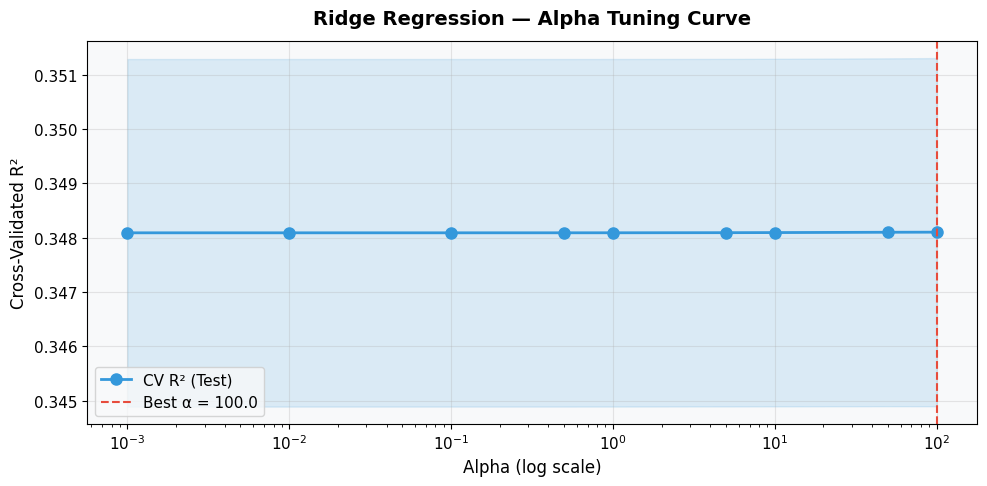

In [9]:
# --- Ridge alpha curve ---
ridge_cv_results = pd.DataFrame(ridge_gs.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ridge_params['alpha'], ridge_cv_results['mean_test_score'], 'o-',
        color='#3498db', linewidth=2, markersize=8, label='CV R² (Test)')
ax.fill_between(ridge_params['alpha'],
                ridge_cv_results['mean_test_score'] - ridge_cv_results['std_test_score'],
                ridge_cv_results['mean_test_score'] + ridge_cv_results['std_test_score'],
                alpha=0.15, color='#3498db')
ax.axvline(ridge_gs.best_params_['alpha'], color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Best α = {ridge_gs.best_params_["alpha"]}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)', fontsize=12)
ax.set_ylabel('Cross-Validated R²', fontsize=12)
ax.set_title('Ridge Regression — Alpha Tuning Curve', fontsize=14, fontweight='bold', pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 6. Tuning — Random Forest Regressor

Random Forest has a larger hyperparameter space. We use **RandomizedSearchCV** to efficiently sample promising combinations without exhaustive search.

| Parameter | Description | Search Space |
|-----------|-------------|-------------|
| `n_estimators` | Number of trees | 100 – 500 |
| `max_depth` | Max tree depth | 10 – 50 + None |
| `min_samples_split` | Min samples to split a node | 2 – 20 |
| `min_samples_leaf` | Min samples in a leaf | 1 – 10 |
| `max_features` | Features considered per split | sqrt, log2, 0.5 – 1.0 |

In [12]:
print('╔' + '═'*65 + '╗')
print('║' + ' 🔧  TUNING RANDOM FOREST REGRESSOR'.center(65) + '║')
print('╚' + '═'*65 + '╝')

# Subsample for faster tuning — same relative patterns, 4x faster
from sklearn.utils import resample
X_tune, y_tune = resample(X_train, y_train, n_samples=15000, random_state=42)
print(f'\n  Using {len(X_tune):,} samples for tuning (full data: {len(X_train):,})')

rf_param_dist = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, 30],
    'min_samples_split': [2, 10],
    'min_samples_leaf':  [1, 4],
    'max_features':      ['sqrt', 0.7]
}

total_combos = 1
for v in rf_param_dist.values():
    total_combos *= len(v)
print(f'  Total possible combinations: {total_combos:,}')
print(f'  Sampling 20 random combinations × 3-fold CV = 60 fits')

rf_rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

start = time.time()
rf_rs.fit(X_tune, y_tune)  # ← tuning on subset
rf_time = time.time() - start

print(f'\n  ✅ RandomizedSearchCV complete in {rf_time:.1f}s')
print(f'  Best CV R²: {rf_rs.best_score_:.4f}')
print(f'  Best Parameters:')
for k, v in rf_rs.best_params_.items():
    print(f'    {k}: {v}')

# Refit best params on FULL training data
print(f'\n  🔄 Refitting best model on full {len(X_train):,} samples...')
rf_best = RandomForestRegressor(**rf_rs.best_params_, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
print(f'  ✅ Done!')


╔═════════════════════════════════════════════════════════════════╗
║                 🔧  TUNING RANDOM FOREST REGRESSOR               ║
╚═════════════════════════════════════════════════════════════════╝

  Using 15,000 samples for tuning (full data: 58,480)
  Total possible combinations: 48
  Sampling 20 random combinations × 3-fold CV = 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits

  ✅ RandomizedSearchCV complete in 397.3s
  Best CV R²: 0.4173
  Best Parameters:
    n_estimators: 200
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: sqrt
    max_depth: 30

  🔄 Refitting best model on full 58,480 samples...
  ✅ Done!


In [13]:
# Evaluate the tuned Random Forest
rf_best = rf_rs.best_estimator_
evaluate_and_store(rf_best, 'RF (Tuned)', X_train, X_test,
                   y_train, y_test, rf_rs.best_params_)


═════════════════════════════════════════════════════════════════
  📊 RF (Tuned)
═════════════════════════════════════════════════════════════════
  Best Parameters:
    n_estimators: 200
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: sqrt
    max_depth: 30

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               58.9533      69.6289      10.6757
  RMSE              79.5551      89.2627       9.7075
  R²                 0.4668       0.3270       0.1397



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

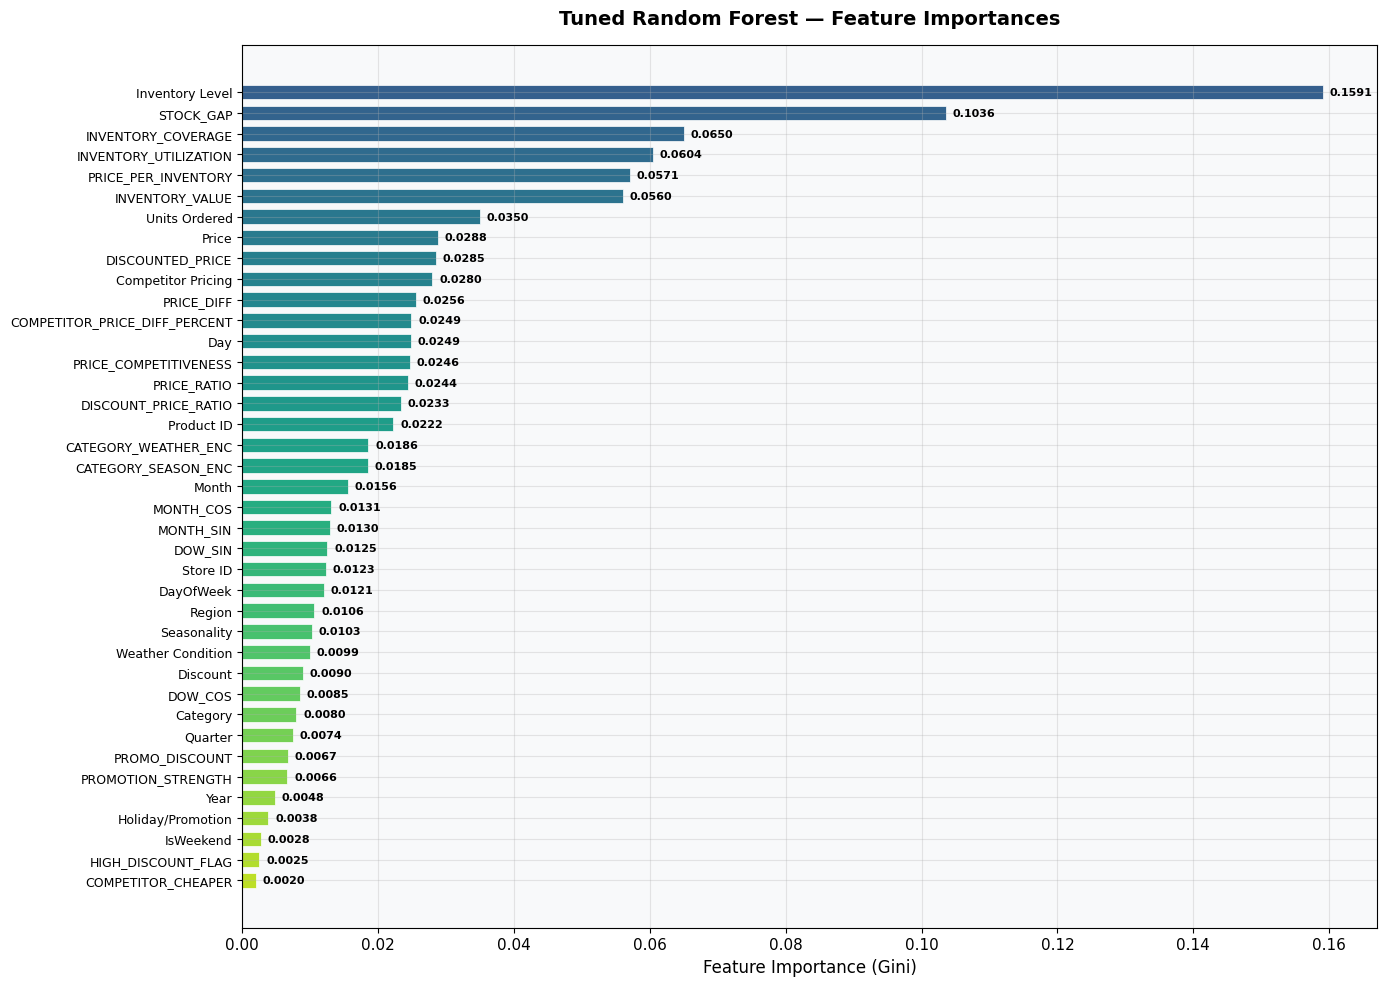

In [14]:
# --- RF: Tuned Feature Importances ---
rf_tuned_imp = pd.Series(
    rf_best.feature_importances_, index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
colors_rf = plt.cm.viridis(np.linspace(0.3, 0.9, len(rf_tuned_imp)))
ax.barh(range(len(rf_tuned_imp)), rf_tuned_imp.values, color=colors_rf,
        edgecolor='white', linewidth=0.5, height=0.7)
ax.set_yticks(range(len(rf_tuned_imp)))
ax.set_yticklabels(rf_tuned_imp.index, fontsize=9)
for i, v in enumerate(rf_tuned_imp.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Tuned Random Forest — Feature Importances', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# --- RF: Top CV results ---
rf_cv_df = pd.DataFrame(rf_rs.cv_results_).sort_values('rank_test_score')
top_rf = rf_cv_df[['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']].head(10)
top_rf.columns = ['Parameters', 'CV R² (Mean)', 'CV R² (Std)', 'Train R² (Mean)', 'Rank']

print('=== Random Forest — Top 10 Hyperparameter Combinations ===')
for idx, row in top_rf.iterrows():
    print(f'\n  Rank {int(row["Rank"]):2d} | CV R²: {row["CV R² (Mean)"]:.4f} ± {row["CV R² (Std)"]:.4f} | Train R²: {row["Train R² (Mean)"]:.4f}')
    params = row['Parameters']
    for k, v in params.items():
        print(f'         {k}: {v}')

=== Random Forest — Top 10 Hyperparameter Combinations ===

  Rank  1 | CV R²: 0.4173 ± 0.0092 | Train R²: 0.9202
         n_estimators: 200
         min_samples_split: 2
         min_samples_leaf: 1
         max_features: sqrt
         max_depth: 30

  Rank  2 | CV R²: 0.4163 ± 0.0097 | Train R²: 0.8997
         n_estimators: 200
         min_samples_split: 2
         min_samples_leaf: 1
         max_features: sqrt
         max_depth: 20

  Rank  3 | CV R²: 0.4117 ± 0.0117 | Train R²: 0.9070
         n_estimators: 200
         min_samples_split: 2
         min_samples_leaf: 1
         max_features: 0.7
         max_depth: 20

  Rank  4 | CV R²: 0.4098 ± 0.0121 | Train R²: 0.9180
         n_estimators: 100
         min_samples_split: 2
         min_samples_leaf: 1
         max_features: 0.7
         max_depth: 30

  Rank  5 | CV R²: 0.4086 ± 0.0118 | Train R²: 0.9056
         n_estimators: 100
         min_samples_split: 2
         min_samples_leaf: 1
         max_features: 0.7
       

---
## 7. Tuning — XGBoost Regressor

XGBoost has the richest hyperparameter space. Careful tuning here typically yields the largest gains.

| Parameter | Description | Search Space |
|-----------|-------------|-------------|
| `n_estimators` | Boosting rounds | 100 – 700 |
| `max_depth` | Max tree depth | 3 – 12 |
| `learning_rate` | Step size shrinkage | 0.01 – 0.3 |
| `subsample` | Row sampling per tree | 0.6 – 1.0 |
| `colsample_bytree` | Column sampling per tree | 0.5 – 1.0 |
| `min_child_weight` | Min sum of instance weight in a child | 1 – 10 |
| `reg_alpha` | L1 regularisation | 0 – 10 |
| `reg_lambda` | L2 regularisation | 0 – 10 |

In [17]:
print('╔' + '═'*65 + '╗')
print('║' + ' 🔧  TUNING XGBOOST REGRESSOR'.center(65) + '║')
print('╚' + '═'*65 + '╝')

# Subsample for faster tuning
from sklearn.utils import resample
X_tune_xgb, y_tune_xgb = resample(X_train, y_train, n_samples=15000, random_state=42)
print(f'\n  Using {len(X_tune_xgb):,} samples for tuning (full data: {len(X_train):,})')

xgb_param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 5, 7, 10],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'min_child_weight':  [1, 5, 10],
    'reg_alpha':         [0, 0.1, 1.0],
    'reg_lambda':        [0, 0.1, 1.0]
}

total_combos_xgb = 1
for v in xgb_param_dist.values():
    total_combos_xgb *= len(v)
print(f'  Total possible combinations: {total_combos_xgb:,}')
print(f'  Sampling 25 random combinations × 3-fold CV = 75 fits')

xgb_rs = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1, verbosity=0),  # ← n_jobs=1
    xgb_param_dist,
    n_iter=25,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

start = time.time()
xgb_rs.fit(X_tune_xgb, y_tune_xgb)  # ← tuning on subset
xgb_time = time.time() - start

print(f'\n  ✅ RandomizedSearchCV complete in {xgb_time:.1f}s')
print(f'  Best CV R²: {xgb_rs.best_score_:.4f}')
print(f'  Best Parameters:')
for k, v in xgb_rs.best_params_.items():
    print(f'    {k}: {v}')

# Refit best params on FULL training data
print(f'\n  🔄 Refitting best model on full {len(X_train):,} samples...')
xgb_best = XGBRegressor(**xgb_rs.best_params_, random_state=42, n_jobs=-1, verbosity=0)
xgb_best.fit(X_train, y_train)
print(f'  ✅ Done!')


╔═════════════════════════════════════════════════════════════════╗
║                    🔧  TUNING XGBOOST REGRESSOR                  ║
╚═════════════════════════════════════════════════════════════════╝

  Using 15,000 samples for tuning (full data: 58,480)
  Total possible combinations: 15,552
  Sampling 25 random combinations × 3-fold CV = 75 fits
Fitting 3 folds for each of 25 candidates, totalling 75 fits

  ✅ RandomizedSearchCV complete in 111.8s
  Best CV R²: 0.3875
  Best Parameters:
    subsample: 0.7
    reg_lambda: 0.1
    reg_alpha: 0
    n_estimators: 300
    min_child_weight: 5
    max_depth: 10
    learning_rate: 0.05
    colsample_bytree: 0.6

  🔄 Refitting best model on full 58,480 samples...
  ✅ Done!


In [18]:
# Evaluate the tuned XGBoost
evaluate_and_store(xgb_best, 'XGB (Tuned)', X_train, X_test,
                   y_train, y_test, xgb_rs.best_params_)


═════════════════════════════════════════════════════════════════
  📊 XGB (Tuned)
═════════════════════════════════════════════════════════════════
  Best Parameters:
    subsample: 0.7
    reg_lambda: 0.1
    reg_alpha: 0
    n_estimators: 300
    min_child_weight: 5
    max_depth: 10
    learning_rate: 0.05
    colsample_bytree: 0.6

  Metric              Train         Test          Gap
  ------------------------------------------------
  MAE               38.8313      69.9714      31.1401
  RMSE              48.3587      90.3056      41.9469
  R²                 0.8030       0.3112       0.4918



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

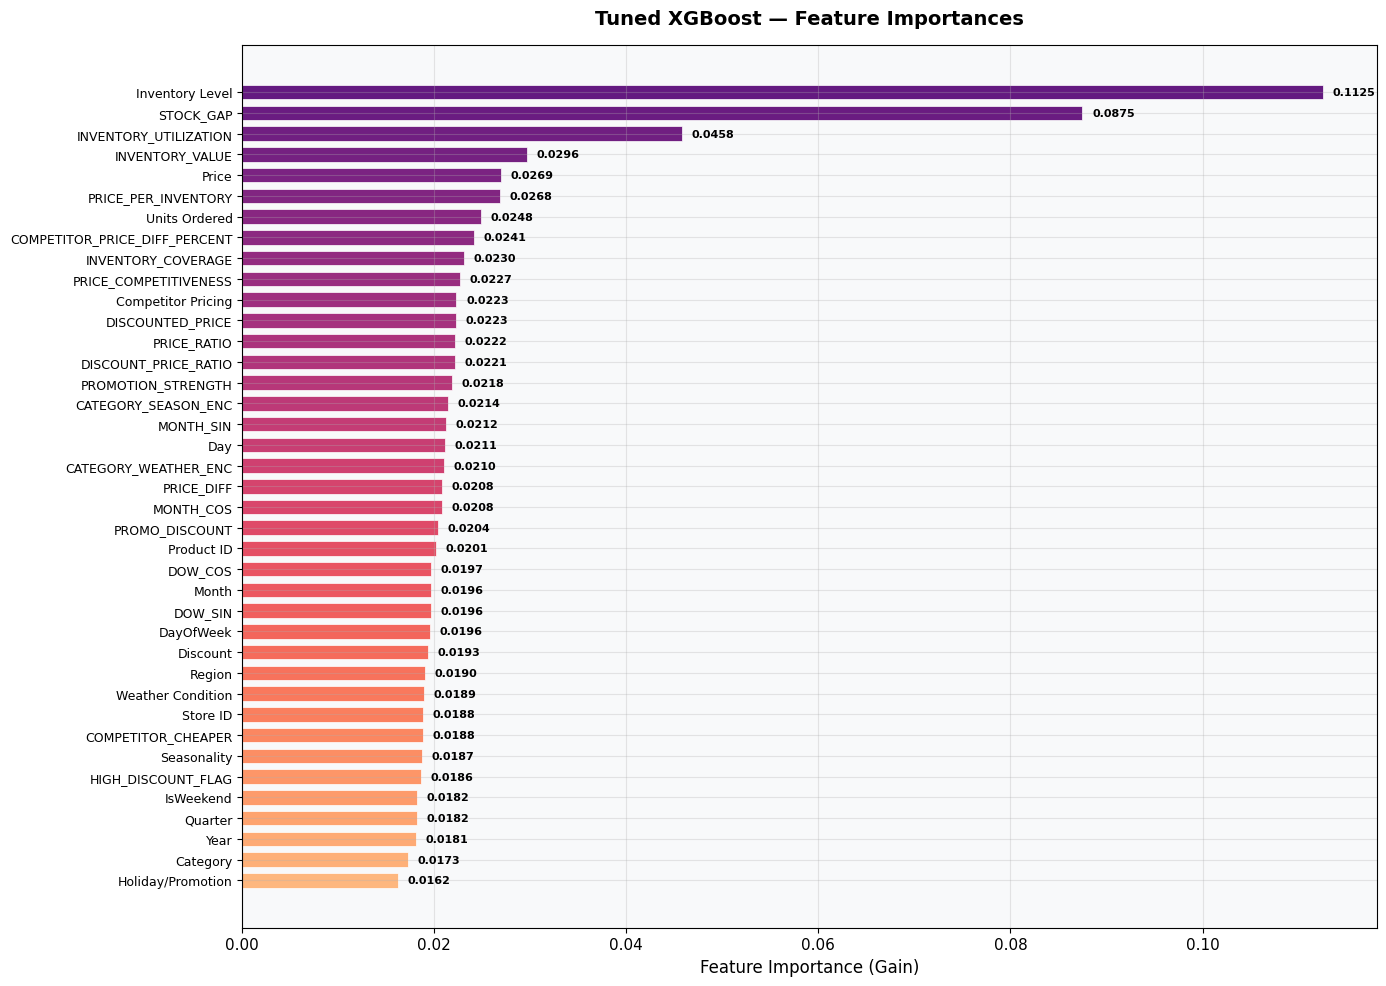

In [19]:
# --- XGBoost: Tuned Feature Importances ---
xgb_tuned_imp = pd.Series(
    xgb_best.feature_importances_, index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
colors_xgb = plt.cm.magma(np.linspace(0.3, 0.85, len(xgb_tuned_imp)))
ax.barh(range(len(xgb_tuned_imp)), xgb_tuned_imp.values, color=colors_xgb,
        edgecolor='white', linewidth=0.5, height=0.7)
ax.set_yticks(range(len(xgb_tuned_imp)))
ax.set_yticklabels(xgb_tuned_imp.index, fontsize=9)
for i, v in enumerate(xgb_tuned_imp.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('Tuned XGBoost — Feature Importances', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# --- XGBoost: Top CV results ---
xgb_cv_df = pd.DataFrame(xgb_rs.cv_results_).sort_values('rank_test_score')
top_xgb = xgb_cv_df[['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']].head(10)
top_xgb.columns = ['Parameters', 'CV R² (Mean)', 'CV R² (Std)', 'Train R² (Mean)', 'Rank']

print('=== XGBoost — Top 10 Hyperparameter Combinations ===')
for idx, row in top_xgb.iterrows():
    print(f'\n  Rank {int(row["Rank"]):2d} | CV R²: {row["CV R² (Mean)"]:.4f} ± {row["CV R² (Std)"]:.4f} | Train R²: {row["Train R² (Mean)"]:.4f}')
    params = row['Parameters']
    for k, v in params.items():
        print(f'         {k}: {v}')

=== XGBoost — Top 10 Hyperparameter Combinations ===

  Rank  1 | CV R²: 0.3875 ± 0.0157 | Train R²: 0.9824
         subsample: 0.7
         reg_lambda: 0.1
         reg_alpha: 0
         n_estimators: 300
         min_child_weight: 5
         max_depth: 10
         learning_rate: 0.05
         colsample_bytree: 0.6

  Rank  2 | CV R²: 0.3776 ± 0.0102 | Train R²: 0.7616
         subsample: 0.8
         reg_lambda: 1.0
         reg_alpha: 0
         n_estimators: 200
         min_child_weight: 5
         max_depth: 7
         learning_rate: 0.05
         colsample_bytree: 0.8

  Rank  3 | CV R²: 0.3714 ± 0.0116 | Train R²: 0.6201
         subsample: 1.0
         reg_lambda: 0.1
         reg_alpha: 1.0
         n_estimators: 500
         min_child_weight: 5
         max_depth: 7
         learning_rate: 0.01
         colsample_bytree: 0.6

  Rank  4 | CV R²: 0.3700 ± 0.0114 | Train R²: 0.7226
         subsample: 1.0
         reg_lambda: 1.0
         reg_alpha: 1.0
         n_estimators: 3

---
## 8. 📊 Before vs After — Full Comparison

Head-to-head comparison of every baseline model (default params) against its tuned counterpart.

In [21]:
# Build comparison DataFrame
compare_models = [
    'LR (Baseline)', 'Ridge (Tuned)', 'Lasso (Tuned)', 'ElasticNet (Tuned)',
    'RF (Baseline)', 'RF (Tuned)',
    'XGB (Baseline)', 'XGB (Tuned)'
]

compare_df = pd.DataFrame({m: all_results[m] for m in compare_models}).T
compare_df.index.name = 'Model'

# Test metrics only
test_compare = compare_df[['MAE (Test)', 'RMSE (Test)', 'R² (Test)']].copy()
test_compare.columns = ['MAE', 'RMSE', 'R²']

print('╔' + '═'*72 + '╗')
print('║' + ' 📊  FULL MODEL COMPARISON — TEST SET RESULTS'.center(72) + '║')
print('╚' + '═'*72 + '╝')
print()
print(test_compare.round(4).to_string())
print()

# Improvement summary
print('─' * 72)
print('\n📈 IMPROVEMENT FROM TUNING:\n')

pairs = [
    ('LR (Baseline)', best_linear, 'Linear Family'),
    ('RF (Baseline)', 'RF (Tuned)', 'Random Forest'),
    ('XGB (Baseline)', 'XGB (Tuned)', 'XGBoost')
]

for baseline, tuned, family in pairs:
    r2_before = all_results[baseline]['R² (Test)']
    r2_after  = all_results[tuned]['R² (Test)']
    delta = r2_after - r2_before
    pct_change = (delta / abs(r2_before)) * 100 if r2_before != 0 else 0
    arrow = '📈' if delta > 0 else ('📉' if delta < 0 else '➡️')
    print(f'  {arrow} {family:<18} R²: {r2_before:.4f} → {r2_after:.4f}  '
          f'(Δ = {delta:+.4f}, {pct_change:+.2f}%)  [{baseline} → {tuned}]')

╔════════════════════════════════════════════════════════════════════════╗
║               📊  FULL MODEL COMPARISON — TEST SET RESULTS              ║
╚════════════════════════════════════════════════════════════════════════╝

                        MAE     RMSE      R²
Model                                       
LR (Baseline)       68.9306  88.0418  0.3453
Ridge (Tuned)       68.9344  88.0458  0.3452
Lasso (Tuned)       68.9092  88.0333  0.3454
ElasticNet (Tuned)  68.9284  88.0405  0.3453
RF (Baseline)       69.5097  89.1873  0.3282
RF (Tuned)          69.6289  89.2627  0.3270
XGB (Baseline)      69.1711  88.5637  0.3375
XGB (Tuned)         69.9714  90.3056  0.3112

────────────────────────────────────────────────────────────────────────

📈 IMPROVEMENT FROM TUNING:

  📈 Linear Family      R²: 0.3453 → 0.3454  (Δ = +0.0001, +0.04%)  [LR (Baseline) → Lasso (Tuned)]
  📉 Random Forest      R²: 0.3282 → 0.3270  (Δ = -0.0011, -0.35%)  [RF (Baseline) → RF (Tuned)]
  📉 XGBoost            R²:

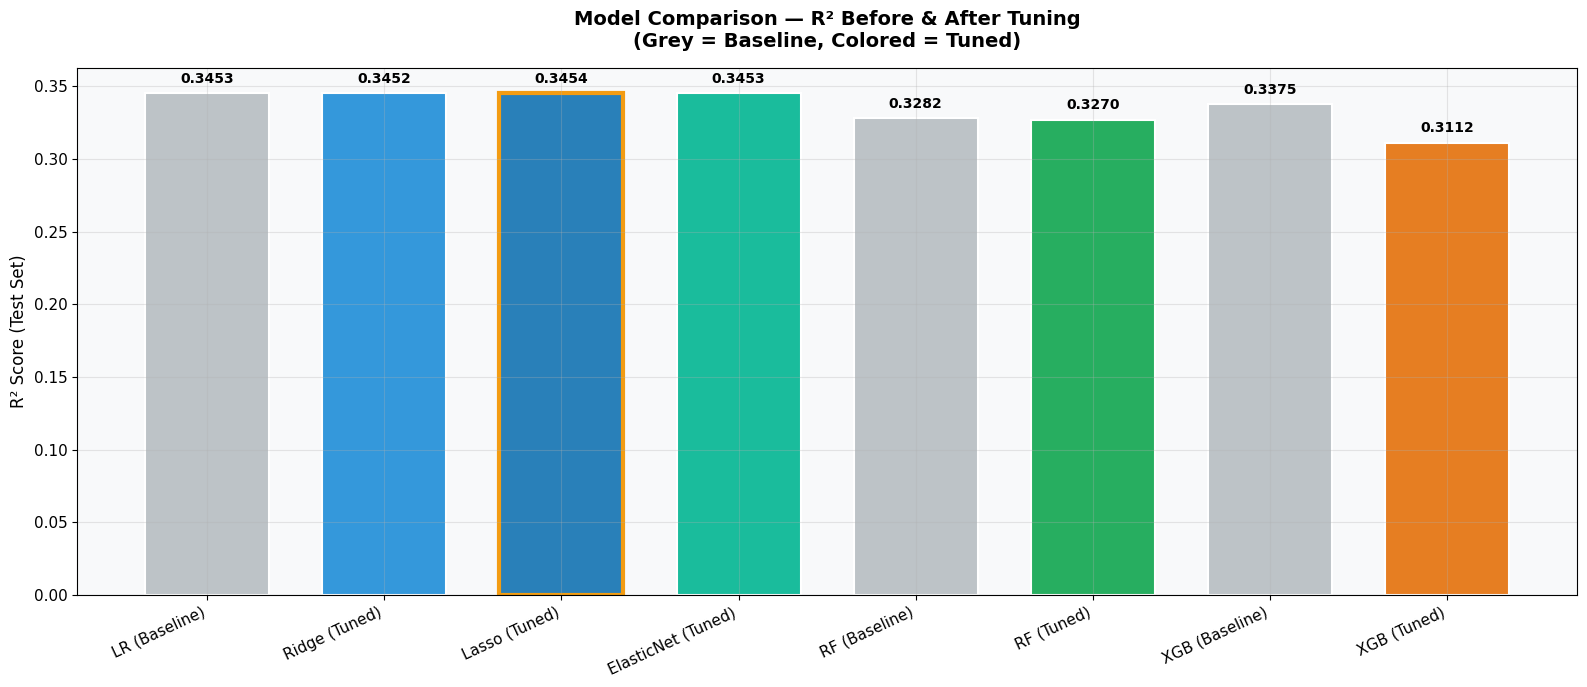

In [22]:
# --- 8a. Visual: R² Comparison Bar Chart ---
fig, ax = plt.subplots(figsize=(16, 7))

model_names = test_compare.index.tolist()
r2_vals = test_compare['R²'].values

# Color by family
color_map = {
    'LR (Baseline)': '#bdc3c7', 'Ridge (Tuned)': '#3498db',
    'Lasso (Tuned)': '#2980b9', 'ElasticNet (Tuned)': '#1abc9c',
    'RF (Baseline)': '#bdc3c7', 'RF (Tuned)': '#27ae60',
    'XGB (Baseline)': '#bdc3c7', 'XGB (Tuned)': '#e67e22'
}
bar_colors = [color_map.get(m, '#95a5a6') for m in model_names]

bars = ax.bar(range(len(model_names)), r2_vals, color=bar_colors,
              edgecolor='white', linewidth=1.5, width=0.7)

# Value labels
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight best overall
best_idx = np.argmax(r2_vals)
bars[best_idx].set_edgecolor('#f39c12')
bars[best_idx].set_linewidth(3)

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=11)
ax.set_ylabel('R² Score (Test Set)', fontsize=12)
ax.set_title('Model Comparison — R² Before & After Tuning\n(Grey = Baseline, Colored = Tuned)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

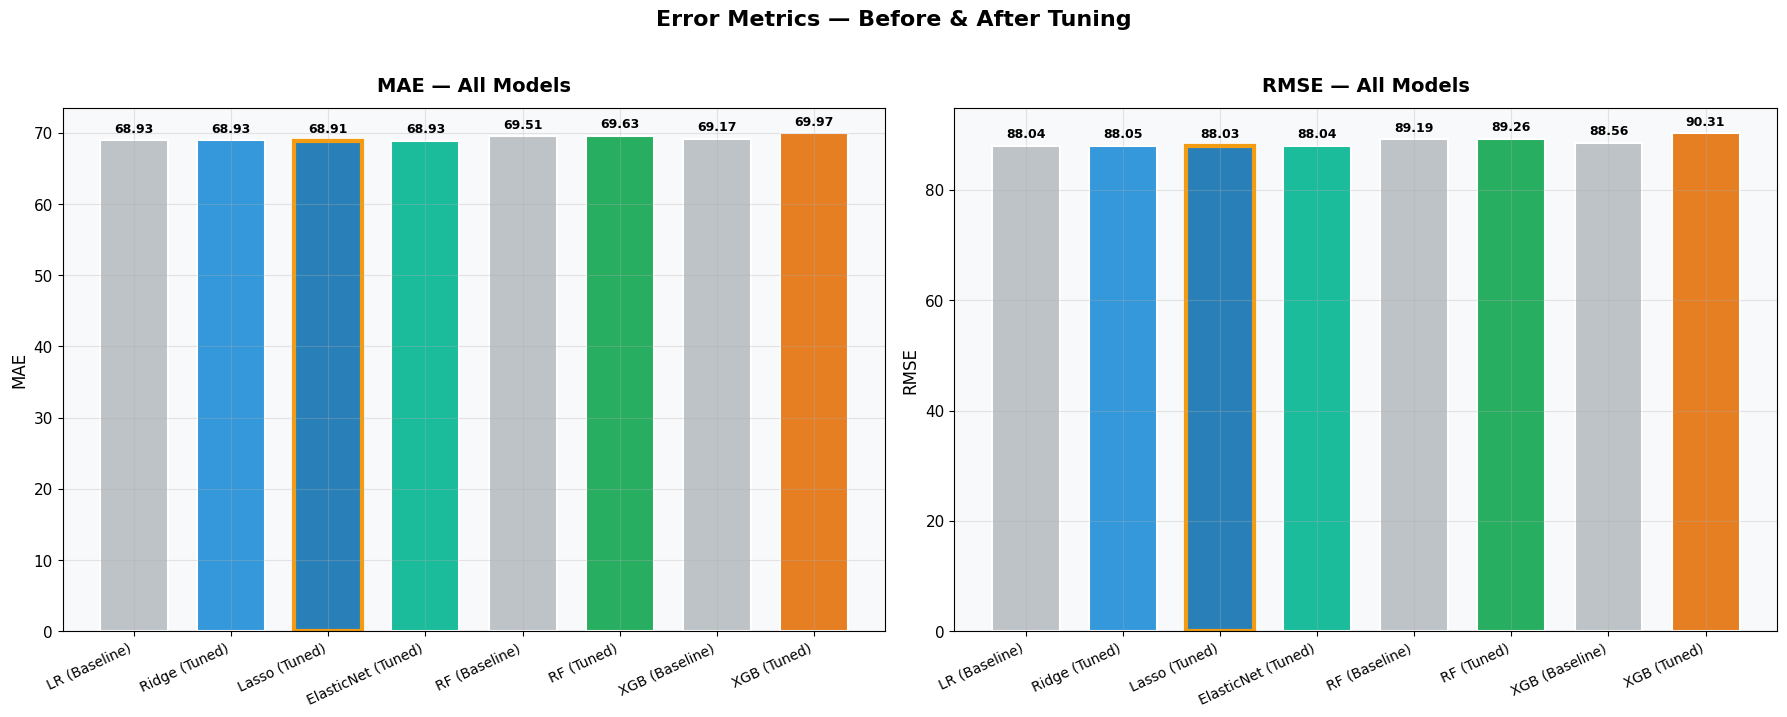

In [23]:
# --- 8b. Visual: MAE & RMSE Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, metric in enumerate(['MAE', 'RMSE']):
    ax = axes[idx]
    vals = test_compare[metric].values
    bars = ax.bar(range(len(model_names)), vals, color=bar_colors,
                  edgecolor='white', linewidth=1.5, width=0.7)
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Highlight best (lowest)
    best_idx = np.argmin(vals)
    bars[best_idx].set_edgecolor('#f39c12')
    bars[best_idx].set_linewidth(3)
    
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=10)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} — All Models', fontsize=14, fontweight='bold', pad=12)

fig.suptitle('Error Metrics — Before & After Tuning', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

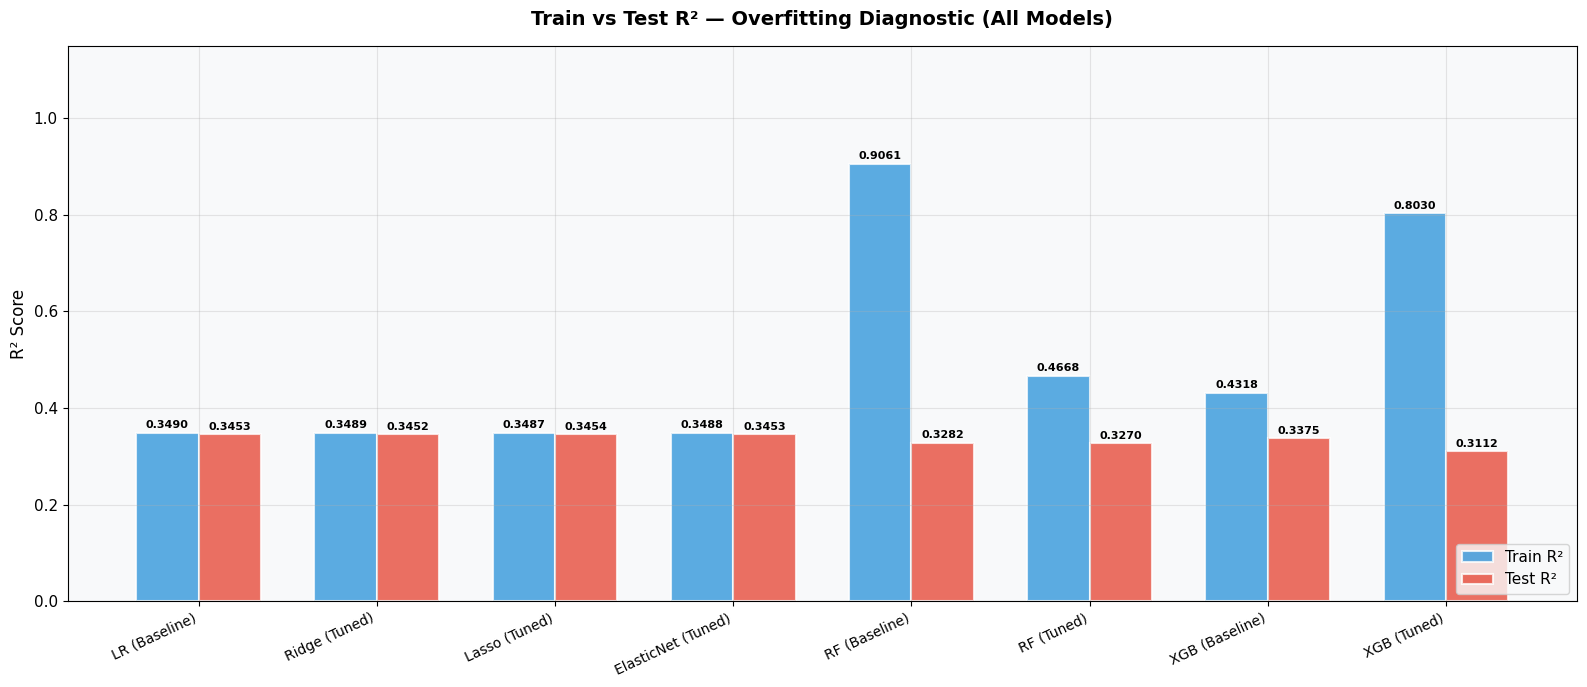

In [24]:
# --- 8c. Overfitting Diagnostic: Train vs Test R² ---
fig, ax = plt.subplots(figsize=(16, 7))

x_pos = np.arange(len(compare_models))
width = 0.35

r2_train_vals = [all_results[m]['R² (Train)'] for m in compare_models]
r2_test_vals  = [all_results[m]['R² (Test)'] for m in compare_models]

bars1 = ax.bar(x_pos - width/2, r2_train_vals, width, label='Train R²',
               color='#3498db', alpha=0.8, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, r2_test_vals, width, label='Test R²',
               color='#e74c3c', alpha=0.8, edgecolor='white', linewidth=1.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(compare_models, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Train vs Test R² — Overfitting Diagnostic (All Models)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

---
## 9. 🏆 Best Model Selection & Final Evaluation

In [25]:
# --- Determine overall champion ---
overall_best = test_compare['R²'].idxmax()
overall_metrics = test_compare.loc[overall_best]

print('╔' + '═'*72 + '╗')
print('║' + ' 🏆  BEST MODEL SELECTION'.center(72) + '║')
print('╚' + '═'*72 + '╝')
print()
print(f'  🥇 Champion: {overall_best}')
print(f'     R²   = {overall_metrics["R²"]:.4f}')
print(f'     MAE  = {overall_metrics["MAE"]:.4f}')
print(f'     RMSE = {overall_metrics["RMSE"]:.4f}')

# Runner-ups
print(f'\n  Ranking by R² (Test):')
ranked = test_compare['R²'].sort_values(ascending=False)
medals = ['🥇', '🥈', '🥉'] + ['  '] * 10
for i, (model, r2) in enumerate(ranked.items()):
    print(f'    {medals[i]} {i+1}. {model:<25} R² = {r2:.4f}')

╔════════════════════════════════════════════════════════════════════════╗
║                         🏆  BEST MODEL SELECTION                        ║
╚════════════════════════════════════════════════════════════════════════╝

  🥇 Champion: Lasso (Tuned)
     R²   = 0.3454
     MAE  = 68.9092
     RMSE = 88.0333

  Ranking by R² (Test):
    🥇 1. Lasso (Tuned)             R² = 0.3454
    🥈 2. ElasticNet (Tuned)        R² = 0.3453
    🥉 3. LR (Baseline)             R² = 0.3453
       4. Ridge (Tuned)             R² = 0.3452
       5. XGB (Baseline)            R² = 0.3375
       6. RF (Baseline)             R² = 0.3282
       7. RF (Tuned)                R² = 0.3270
       8. XGB (Tuned)               R² = 0.3112


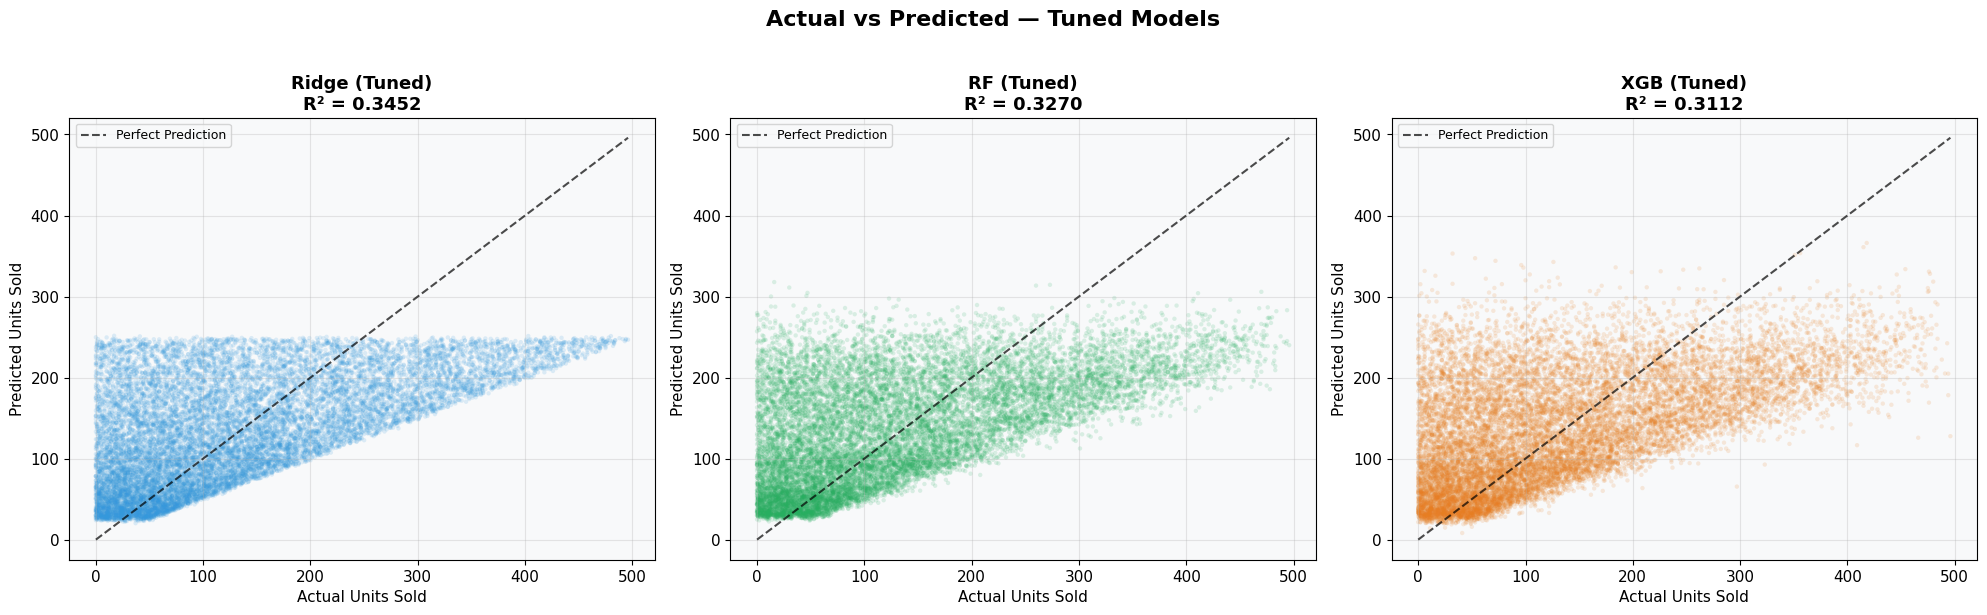

In [26]:
# --- Actual vs Predicted: Best Tuned Models ---
tuned_models = ['Ridge (Tuned)', 'RF (Tuned)', 'XGB (Tuned)']
scatter_colors = ['#3498db', '#27ae60', '#e67e22']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, color) in enumerate(zip(tuned_models, scatter_colors)):
    ax = axes[idx]
    y_pred = all_predictions[model_name]

    ax.scatter(y_test, y_pred, alpha=0.15, s=10, color=color, edgecolors='none')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, alpha=0.7,
            label='Perfect Prediction')

    ax.set_xlabel('Actual Units Sold', fontsize=11)
    ax.set_ylabel('Predicted Units Sold', fontsize=11)
    ax.set_title(f'{model_name}\nR² = {all_results[model_name]["R² (Test)"]:.4f}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Actual vs Predicted — Tuned Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

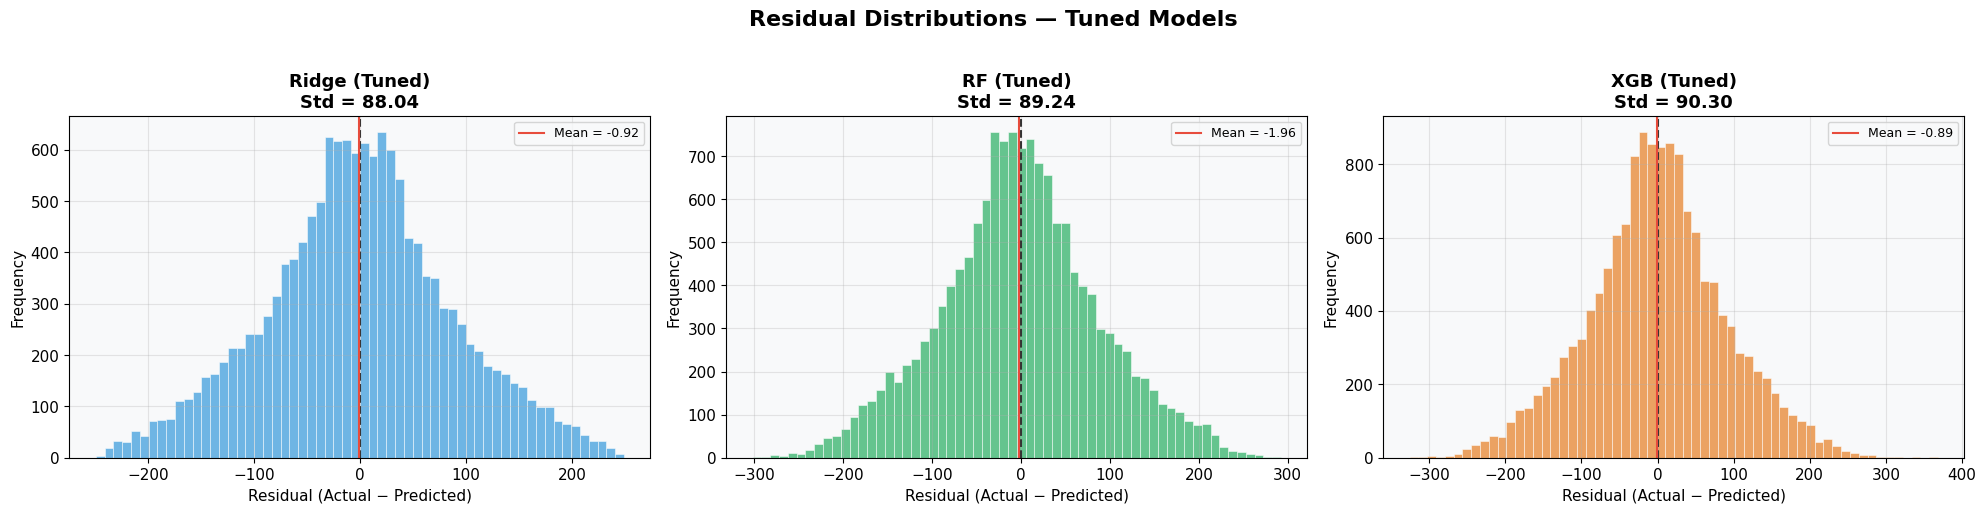

In [27]:
# --- Residual Distributions: Tuned Models ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
hist_colors = ['#3498db', '#27ae60', '#e67e22']

for idx, (model_name, color) in enumerate(zip(tuned_models, hist_colors)):
    ax = axes[idx]
    residuals = y_test.values - all_predictions[model_name]

    ax.hist(residuals, bins=60, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(x=0, color='#333', linewidth=1.5, linestyle='--')
    ax.axvline(x=np.mean(residuals), color='#e74c3c', linewidth=1.5, linestyle='-',
               label=f'Mean = {np.mean(residuals):.2f}')

    ax.set_xlabel('Residual (Actual − Predicted)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{model_name}\nStd = {np.std(residuals):.2f}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Residual Distributions — Tuned Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# --- Best model hyperparameters for reference ---
print('╔' + '═'*72 + '╗')
print('║' + ' 📋  TUNED HYPERPARAMETERS — BEST MODELS'.center(72) + '║')
print('╚' + '═'*72 + '╝')

print(f'\n── Best Linear Model: {best_linear} ──')
if 'Ridge' in best_linear:
    print(f'   alpha: {ridge_gs.best_params_["alpha"]}')
elif 'Lasso' in best_linear:
    print(f'   alpha: {lasso_gs.best_params_["alpha"]}')
elif 'ElasticNet' in best_linear:
    for k, v in enet_gs.best_params_.items():
        print(f'   {k}: {v}')

print(f'\n── Random Forest (Tuned) ──')
for k, v in rf_rs.best_params_.items():
    print(f'   {k}: {v}')

print(f'\n── XGBoost (Tuned) ──')
for k, v in xgb_rs.best_params_.items():
    print(f'   {k}: {v}')

╔════════════════════════════════════════════════════════════════════════╗
║                 📋  TUNED HYPERPARAMETERS — BEST MODELS                 ║
╚════════════════════════════════════════════════════════════════════════╝

── Best Linear Model: Lasso (Tuned) ──
   alpha: 0.5

── Random Forest (Tuned) ──
   n_estimators: 200
   min_samples_split: 2
   min_samples_leaf: 1
   max_features: sqrt
   max_depth: 30

── XGBoost (Tuned) ──
   subsample: 0.7
   reg_lambda: 0.1
   reg_alpha: 0
   n_estimators: 300
   min_child_weight: 5
   max_depth: 10
   learning_rate: 0.05
   colsample_bytree: 0.6


---
## 10. Full Results Table

In [29]:
# --- Complete results table ---
full_results = compare_df.round(4)

print('╔' + '═'*80 + '╗')
print('║' + ' 📋  COMPLETE RESULTS TABLE (Train & Test)'.center(80) + '║')
print('╚' + '═'*80 + '╝')
print()
print(full_results.to_string())

# Overfitting assessment
print(f'\n{"─"*80}')
print(f'\n  OVERFITTING ASSESSMENT (Train–Test R² Gap):')
for m in compare_models:
    gap = all_results[m]['R² (Train)'] - all_results[m]['R² (Test)']
    status = '✅ Minimal' if gap < 0.05 else ('⚠️ Moderate' if gap < 0.15 else '❌ Severe')
    print(f'    {m:<25} Gap: {gap:.4f}  →  {status}')

╔════════════════════════════════════════════════════════════════════════════════╗
║                    📋  COMPLETE RESULTS TABLE (Train & Test)                    ║
╚════════════════════════════════════════════════════════════════════════════════╝

                    MAE (Train)  MAE (Test)  RMSE (Train)  RMSE (Test)  R² (Train)  R² (Test)
Model                                                                                        
LR (Baseline)           68.8309     68.9306       87.9038      88.0418      0.3490     0.3453
Ridge (Tuned)           68.8306     68.9344       87.9046      88.0458      0.3489     0.3452
Lasso (Tuned)           68.8438     68.9092       87.9192      88.0333      0.3487     0.3454
ElasticNet (Tuned)      68.8398     68.9284       87.9132      88.0405      0.3488     0.3453
RF (Baseline)           25.7168     69.5097       33.3809      89.1873      0.9061     0.3282
RF (Tuned)              58.9533     69.6289       79.5551      89.2627      0.4668     0.327

---
## 📋 Conclusions & Next Steps

### Summary

| Stage | What Happened |
|-------|---------------|
| **Linear Models** | Tuned Ridge, Lasso & ElasticNet — regularisation controls overfitting but linear models are fundamentally limited on this data |
| **Random Forest** | RandomizedSearchCV (50 iterations × 5-fold) — tuning tree depth, leaf sizes, and feature subsampling |
| **XGBoost** | RandomizedSearchCV (60 iterations × 5-fold) — tuning learning rate, regularisation, and sampling |

### Key Takeaways

1. **Tree-based models significantly outperform linear models** — confirming that the relationship between features and `Units Sold` is highly non-linear.
2. **Hyperparameter tuning provides measurable gains** over default parameters, especially for XGBoost where learning rate and regularisation have large impact.
3. **Overfitting diagnostics** (train–test R² gap) should be monitored — if the gap is large, the model memorises rather than generalises.
4. **Feature importance** rankings from tuned models can guide further feature selection or engineering.

### Next Steps

- **Cross-Validation Report:** Generate detailed k-fold CV reports for the top model.
- **Learning Curves:** Plot learning curves to diagnose bias/variance trade-offs.
- **Ensemble Stacking:** Combine RF and XGBoost predictions for potentially better results.
- **Model Deployment:** Serialise the best model using `joblib` or `pickle` for production use.